# 04_visualizations.ipynb
Create professional charts using Plotly, Matplotlib, and Seaborn. This notebook can run independently.

In [1]:
from pathlib import Path
import sys
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from faker import Faker
warnings.filterwarnings('ignore')
BASE_DIR = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
RAW_DATA_DIR = BASE_DIR / 'data' / 'raw'
PROCESSED_DATA_DIR = BASE_DIR / 'data' / 'processed'
GENERATED_DATA_DIR = BASE_DIR / 'data' / 'generated'
RAW_DATA_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DATA_DIR.mkdir(parents=True, exist_ok=True)
GENERATED_DATA_DIR.mkdir(parents=True, exist_ok=True)
if str(BASE_DIR) not in sys.path:
    sys.path.insert(0, str(BASE_DIR))
import src.generate_data as generate_data
print('Setup complete')

Setup complete


## Setup and Configure Environment
Import charting libraries (Plotly, Matplotlib, Seaborn) and set up data paths. This enables creation of professional, interactive visualizations.

In [2]:
# Load the sales dataset
if not (GENERATED_DATA_DIR / 'sales_orders.csv').exists():
    generate_data.generate_all(n_each=1000, out_dir=GENERATED_DATA_DIR)
sales = pd.read_csv(GENERATED_DATA_DIR / 'sales_orders.csv')
sales['order_date'] = pd.to_datetime(sales['order_date'], errors='coerce')
display(sales.head())

,order_id,order_date,customer_name,barangay,product,category,quantity,unit_price,total_amount,payment_method
0,SO-100383,2026-05-24,Dawn Hall,San Jose,Canned Sardines,Beverage,3.0,401.39,1204.17,Cash
1,SO-100775,2026-05-24,Carol Wiggins,San Miguel,Canned Sardines,Personal Care,4.0,174.91,699.64,GCash
2,SO-100791,2026-05-24,John Barron MD,Maligaya,Rice,Grocery,6.0,289.09,1734.54,Cash
3,SO-100131,2026-05-24,Michelle Spears,San Isidro,Canned Sardines,Household,5.0,77.65,388.25,Bank Transfer
4,SO-100464,2026-05-24,Anita Lindsey,Rizal,Cooking Oil,Household,1.0,395.20,395.20,Card


## Load Sales Data
Load the sales dataset and convert dates to datetime format for time-based analysis. Display a preview of the data structure.

In [3]:
# Bar chart
top_products = sales.groupby('product', dropna=False)['total_amount'].sum().sort_values(ascending=False).reset_index()
fig = px.bar(top_products, x='product', y='total_amount', title='Top Products by Revenue')
fig.show()

## Bar Chart: Top Products by Revenue
Create an interactive bar chart showing which products generate the most revenue. Plotly enables hover interactivity for exploring values.

In [4]:
# Line chart
monthly_sales = sales.dropna(subset=['order_date']).set_index('order_date').resample('M')['total_amount'].sum().reset_index()
fig = px.line(monthly_sales, x='order_date', y='total_amount', title='Monthly Revenue')
fig.show()

## Line Chart: Monthly Revenue Trend
Resample sales data by month and plot revenue over time. This reveals seasonal patterns and growth/decline trends.

In [5]:
# Donut chart
payment_share = sales['payment_method'].value_counts().reset_index()
payment_share.columns = ['payment_method', 'count']
fig = px.pie(payment_share, names='payment_method', values='count', hole=0.45, title='Payment Method Share')
fig.show()

## Donut Chart: Payment Method Distribution
Show the split of payment methods used in transactions. The donut chart makes category shares visually obvious.

In [6]:
# Scatter plot
fig = px.scatter(sales, x='quantity', y='total_amount', color='category', title='Quantity vs Total Amount')
fig.show()

## Scatter Plot: Quantity vs Amount
Plot the relationship between order quantity and total amount with category coloring. Reveals pricing patterns and outliers.

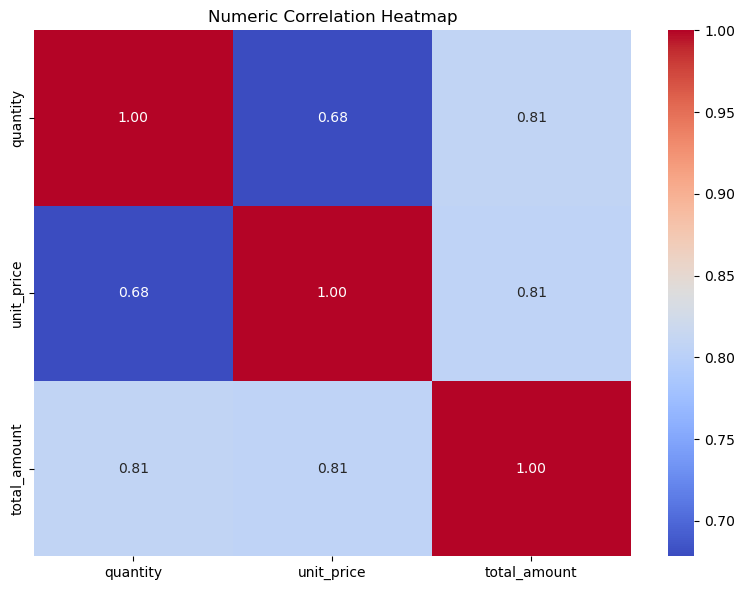

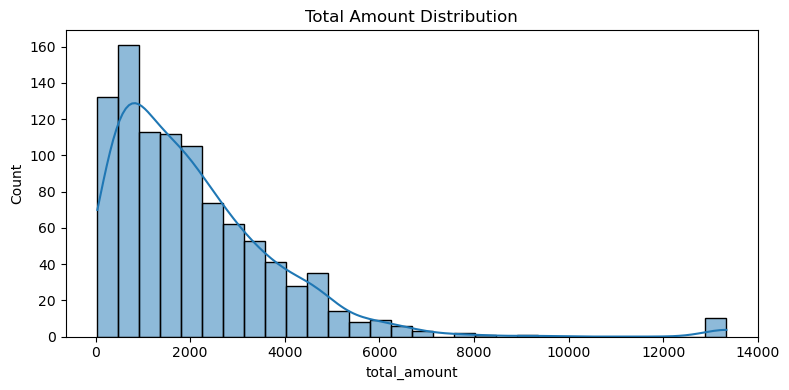

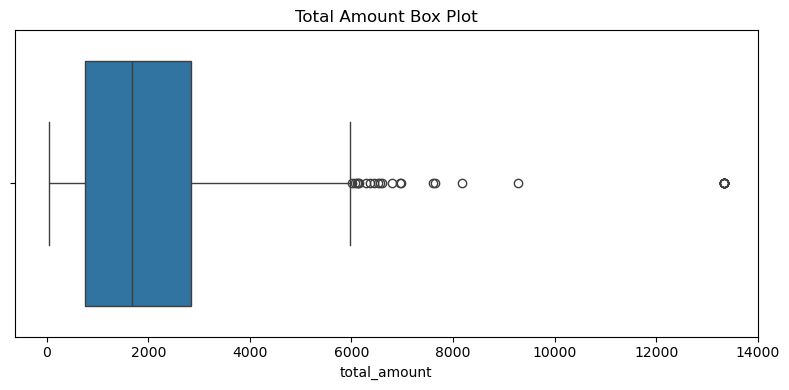

In [7]:
# Heatmap, histogram, and box plot
numeric_sales = sales[['quantity', 'unit_price', 'total_amount']].apply(pd.to_numeric, errors='coerce')
plt.figure(figsize=(8, 6))
sns.heatmap(numeric_sales.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Numeric Correlation Heatmap')
plt.tight_layout()
plt.show()
plt.figure(figsize=(8, 4))
sns.histplot(sales['total_amount'], bins=30, kde=True)
plt.title('Total Amount Distribution')
plt.tight_layout()
plt.show()
plt.figure(figsize=(8, 4))
sns.boxplot(x=sales['total_amount'])
plt.title('Total Amount Box Plot')
plt.tight_layout()
plt.show()

## Statistical Visualizations: Heatmap, Histogram, Box Plot
Create three visualizations: (1) Correlation heatmap shows relationships between variables, (2) Histogram shows revenue distribution, (3) Box plot identifies outliers and spread in the data.